# CosmoFit Modified Gravity & Growth of Structure

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/salihyesil59/CosmoFit/blob/main/examples/modified_gravity_growth.ipynb)

CosmoFit's three modified-gravity models -- **FQExponential** (f(Q)),
**FRTLinear** (f(R,T)), and **FRHuSawicki** (f(R)) -- genuinely modify
the gravitational field equations, rather than reparametrizing dark
energy on top of standard GR the way LCDM/wCDM/CPL/JBP/BA/GCG do. This
notebook covers both levels these models are tested at:

- **Background (E(z))**: FQExponential and FRTLinear have their own
  E(z), different from LCDM's. **FRHuSawicki's background is
  identical to LCDM's by construction** ("designer f(R)") -- its
  `f_R0`/`n` parameters are invisible to *any* background probe
  (CC, BAO, SNe, Planck distance priors).
- **Growth of structure**: every model has an effective gravitational
  coupling `mu(a,k)` (1 = standard GR; overridden by the three MG
  models above) entering the linear growth equation
  (`cosmology.calculators.growth.GrowthCalculator`), predicting
  fsigma8(z) and S8 = sigma8*sqrt(Omega_m/0.3) -- **this is where
  FRHuSawicki actually differs from LCDM**, and where `f_R0`/`n`
  become genuinely constrainable.

**Running this notebook:** open in Colab and *Runtime -> Run all*
(~2-3 minutes -- two short MCMC runs).

## Setup

In [1]:
import sys, os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    if not os.path.exists("CosmoFit"):
        !git clone --quiet -b dev https://github.com/salihyesil59/CosmoFit.git
    %cd CosmoFit
    !pip install -q -e .
else:
    print("Not running in Colab -- assuming CosmoFit is already installed "
          "(pip install -e . from the repository root).")


Not running in Colab -- assuming CosmoFit is already installed (pip install -e . from the repository root).


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from CosmoFit import LCDM, FQExponential, FRTLinear, FRHuSawicki, Fitter

%matplotlib inline
plt.rcParams["figure.dpi"] = 110
np.random.seed(0)

FIDUCIAL = {
    "H0": 67.4, "Omega_m": 0.315, "rd": 147.1, "Omega_b": 0.0493,
    "sigma8": 0.811,
    "Omega_L": 0.685, "beta": 0.0,   # FRTLinear
    "f_R0": -1e-6, "n": 1.0,          # FRHuSawicki
}


## Background: E(z) for the three MG models vs LCDM

FQExponential and FRTLinear have their own expansion history;
FRHuSawicki's is exactly LCDM's (the two curves below overlap
completely -- that's the point, not a bug).

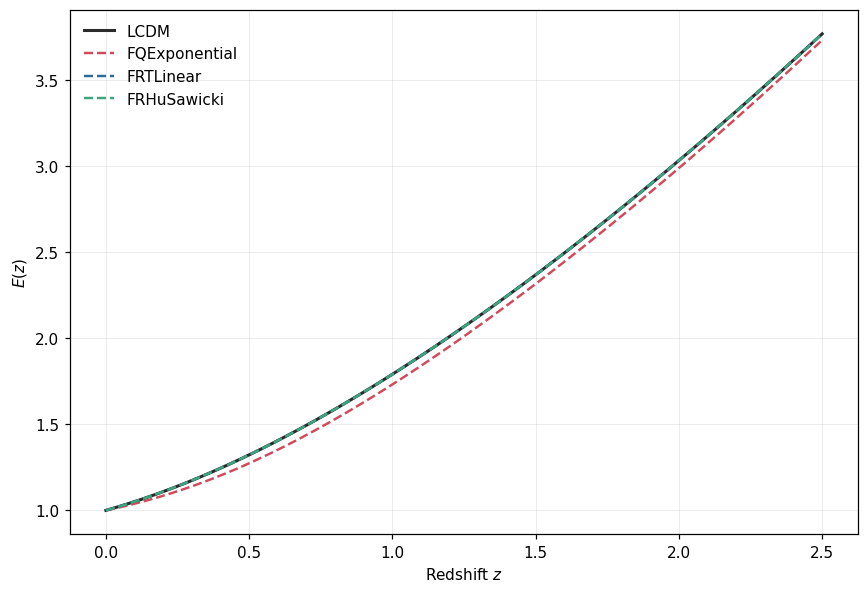

In [3]:
from CosmoFit.cosmology.core.parameters import CosmologyParameters

z = np.linspace(0.0, 2.5, 200)

fig, ax = plt.subplots(figsize=(8, 5.5))

lcdm = LCDM(CosmologyParameters(**{k: v for k, v in FIDUCIAL.items()
                                    if k in CosmologyParameters.names()}))
ax.plot(z, lcdm.E(z), color="#2b2b2b", lw=2.0, label="LCDM")

for name, model_cls, color in [
    ("FQExponential", FQExponential, "#d1495b"),
    ("FRTLinear", FRTLinear, "#2b6a99"),
    ("FRHuSawicki", FRHuSawicki, "#3ca67a"),
]:
    params_cls = model_cls.PARAMS_CLASS
    values = dict(params_cls.defaults())
    values.update({k: v for k, v in FIDUCIAL.items() if k in params_cls.names()})
    cosmo = model_cls(params_cls(**values))
    ax.plot(z, cosmo.E(z), color=color, lw=1.6, ls="--", label=name)

ax.set_xlabel("Redshift $z$")
ax.set_ylabel("$E(z)$")
ax.legend(frameon=False)
ax.grid(alpha=0.25, linewidth=0.6)
fig.tight_layout()


## Growth of structure: fsigma8(z)

Every model gets a linear growth factor D(z), growth rate f(z), and
fsigma8(z) = f(z)*sigma8(z) from `GrowthCalculator`, driven by the
model's own `E(z)`/`dEdz` plus its `mu(a,k)` hook (default 1, i.e.
standard GR growth). `fitter.plots.growth()` plots the model curve
against the "Gold-2018" RSD compilation (22 points).

LCDM fiducial chi2 against fsigma8: 17.44 (22 points)


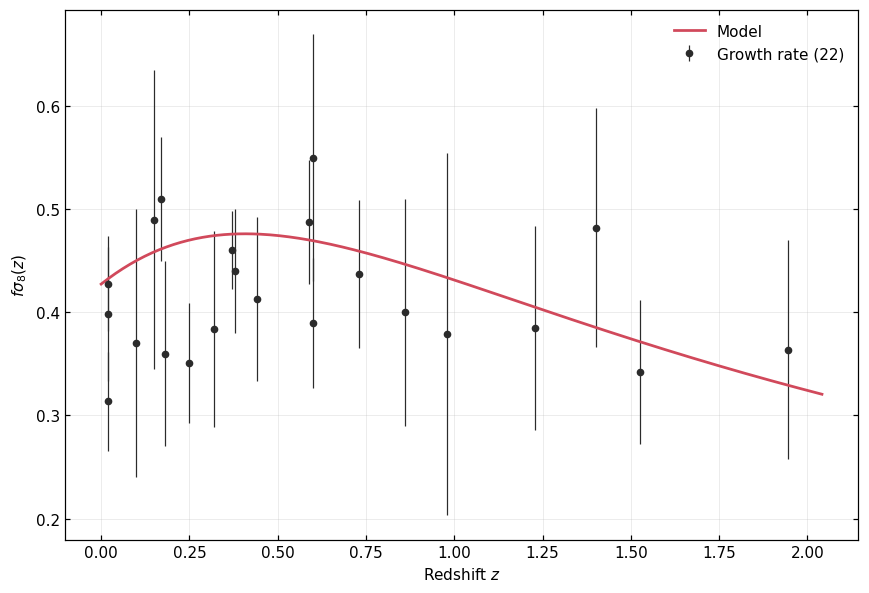

In [4]:
fit_lcdm_growth = Fitter(
    model=LCDM, datasets=["fsigma8"],
    free_params=["Omega_m", "sigma8"], initial=FIDUCIAL,
)
fig = fit_lcdm_growth.plots.growth()
print(f"LCDM fiducial chi2 against fsigma8: {fit_lcdm_growth.chi2():.2f} "
      f"({fit_lcdm_growth.n_data} points)")


## mu(a,k): how each modified-gravity model actually differs

- **FQExponential**: `mu(a) = 1/f_Q`, scale-independent.
- **FRTLinear**: `mu(a) = 1 + 3*beta`, scale-independent (a stated
  simplification -- see the class docstring).
- **FRHuSawicki**: `mu(a,k)` is scale- *and* time-dependent
  (chameleon screening) -- this is the one with real structure to
  show.

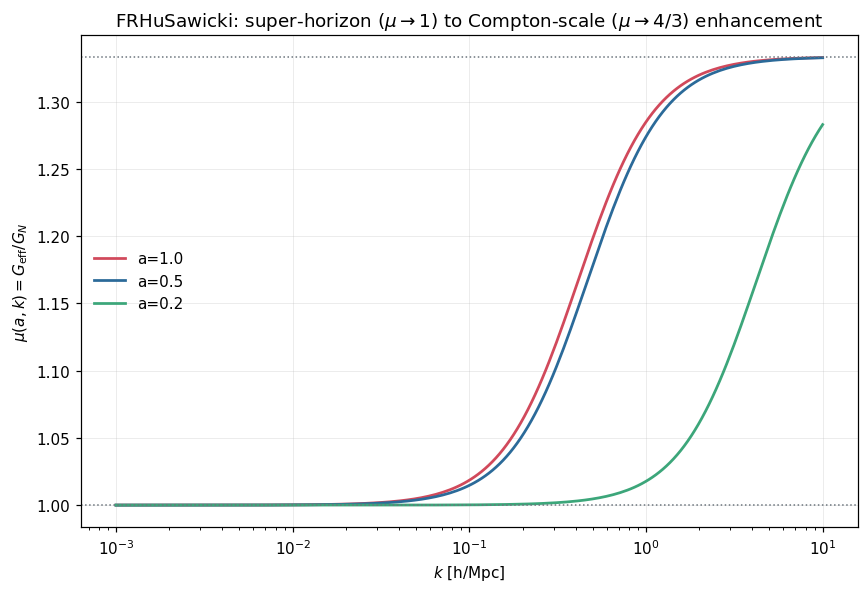

In [5]:
k_grid = np.logspace(-3, 1, 200)  # h/Mpc

fr_params = FRHuSawicki.PARAMS_CLASS
values = dict(fr_params.defaults())
values.update({k: v for k, v in FIDUCIAL.items() if k in fr_params.names()})
fr = FRHuSawicki(fr_params(**values))

fig, ax = plt.subplots(figsize=(8, 5.5))
for a, color in [(1.0, "#d1495b"), (0.5, "#2b6a99"), (0.2, "#3ca67a")]:
    ax.plot(k_grid, fr.mu(a, k=k_grid), color=color, lw=1.8, label=f"a={a}")

ax.axhline(1.0, color="#6c757d", lw=1.0, ls=":")
ax.axhline(4.0 / 3.0, color="#6c757d", lw=1.0, ls=":")
ax.set_xscale("log")
ax.set_xlabel("$k$ [h/Mpc]")
ax.set_ylabel(r"$\mu(a,k) = G_\mathrm{eff}/G_N$")
ax.set_title(r"FRHuSawicki: super-horizon ($\mu\to1$) to Compton-scale ($\mu\to4/3$) enhancement")
ax.legend(frameon=False)
ax.grid(alpha=0.25, linewidth=0.6)
fig.tight_layout()


## Background-only: f_R0 is invisible

Fit FRHuSawicki against CC+DESI (both background probes) with `f_R0`
free. Since `E(z)` never uses `f_R0`, the chi2 is completely flat
across its entire prior range -- confirmed directly below rather than
asserted.

In [6]:
fit_bg = Fitter(
    model=FRHuSawicki, datasets=["cc", "desi"],
    free_params=["H0", "Omega_m", "f_R0"], initial=FIDUCIAL,
    bounds={"f_R0": (-1e-4, -1e-8)},
)

f_R0_grid = np.linspace(-1e-4, -1e-8, 25)
chi2_vals = [fit_bg.chi2([FIDUCIAL["H0"], FIDUCIAL["Omega_m"], f_R0])
             for f_R0 in f_R0_grid]

print(f"chi2 range as f_R0 sweeps its whole prior: "
      f"[{min(chi2_vals):.6f}, {max(chi2_vals):.6f}]  (background-only data)")


chi2 range as f_R0 sweeps its whole prior: [34.050182, 34.050182]  (background-only data)


## Growth data constrains it: a real MCMC fit

Now fit FRHuSawicki against `"fsigma8"` (+ the KiDS-1000 `"s8"`
prior), with `f_R0` free -- this time its posterior should be a real,
bounded distribution, not flat across the prior.

In [7]:
fit_growth = Fitter(
    model=FRHuSawicki, datasets=["fsigma8", "s8"],
    free_params=["Omega_m", "sigma8", "f_R0"], initial=FIDUCIAL,
    bounds={"f_R0": (-1e-4, -1e-8)},
)
fit_growth.run_mcmc(nwalkers=24, nsteps=600, burnin=150, progress=False)

conv = fit_growth.convergence()
print("converged:", conv["converged"])
print()

for name, s in fit_growth.summary().items():
    print(f"  {name:>10s} = {s['median']:.4g}  "
          f"+{s['plus']:.4g} -{s['minus']:.4g}")


The chain is shorter than 50 times the integrated autocorrelation time for 3 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 12;
tau: [31.33909472 32.33750084 36.22247093]


converged: False

     Omega_m = 0.2804  +0.03805 -0.03605
      sigma8 = 0.7667  +0.0525 -0.04388
        f_R0 = -1.093e-05  +8.595e-06 -3.471e-05


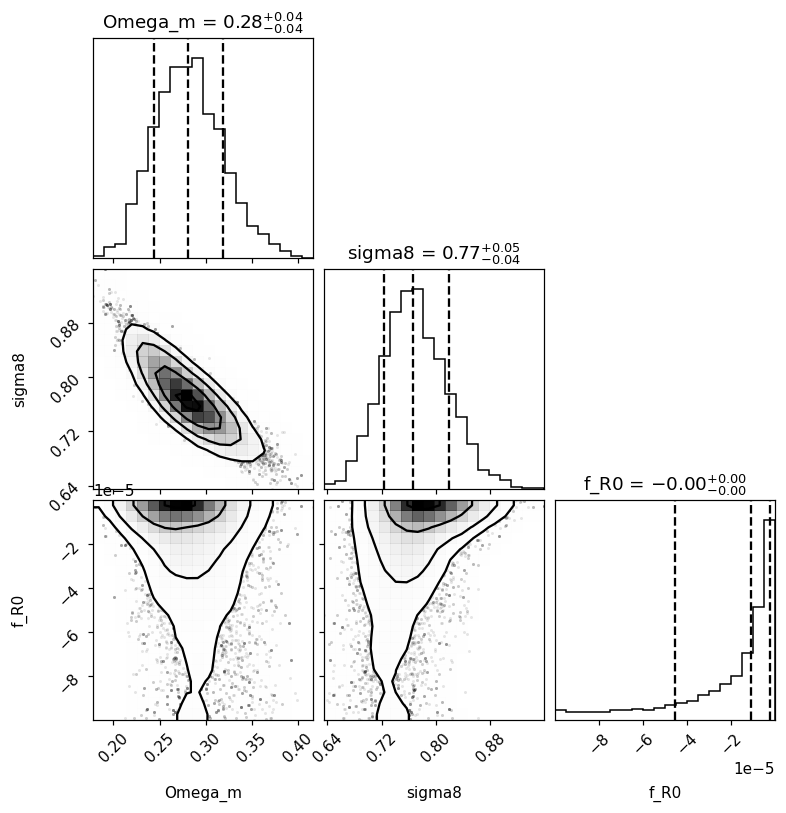

In [8]:
fig = fit_growth.plots.corner()


`f_R0`'s posterior above is a real, bounded peak, not a flat line
across `[-1e-4, -1e-8]` the way the background-only sweep was -- the
whole point of this notebook.

(This particular chain is kept short for runtime -- `fit_growth.convergence()` reports it hasn't fully converged yet, honestly, rather than silently -- but the qualitative point, a real peaked posterior instead of a flat line, already holds; run more steps for a publication-grade posterior.)

## FRHuSawicki vs LCDM: growth-rate comparison

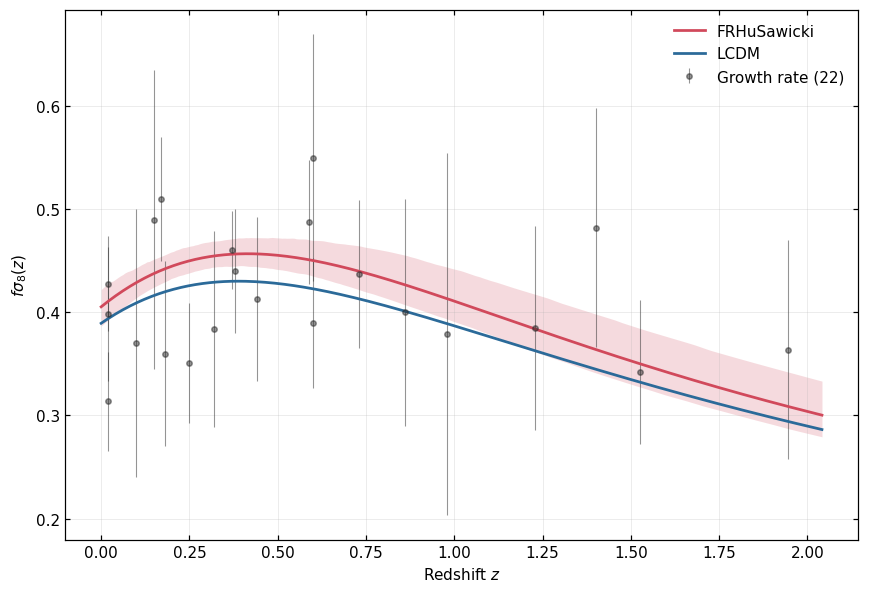

In [9]:
fig = fit_growth.plots.compare_growth(labels=["FRHuSawicki", "LCDM"])


## FQExponential and FRTLinear: growth also differs from LCDM

Unlike FRHuSawicki, these two already have a different *background*
-- but their growth differs too, through their own (scale-independent)
`mu(a)`.

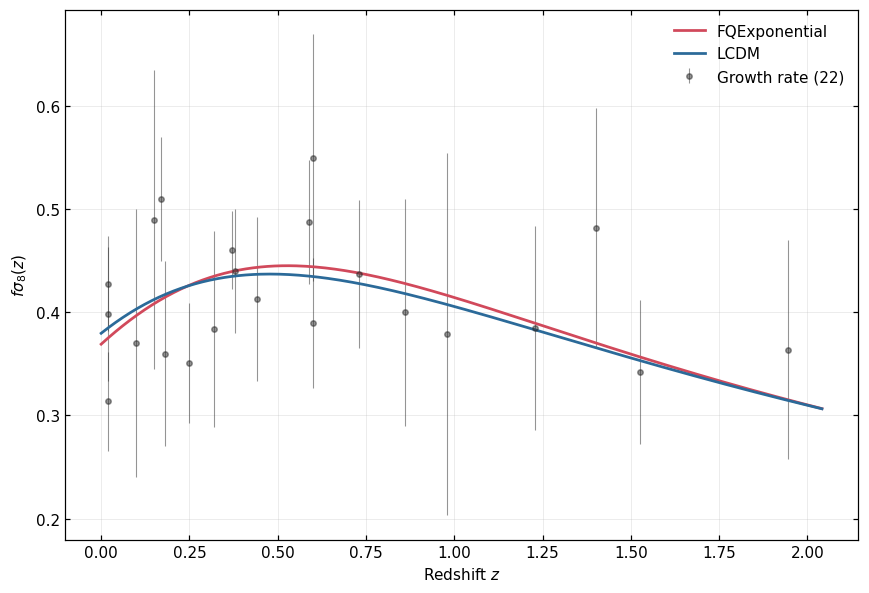

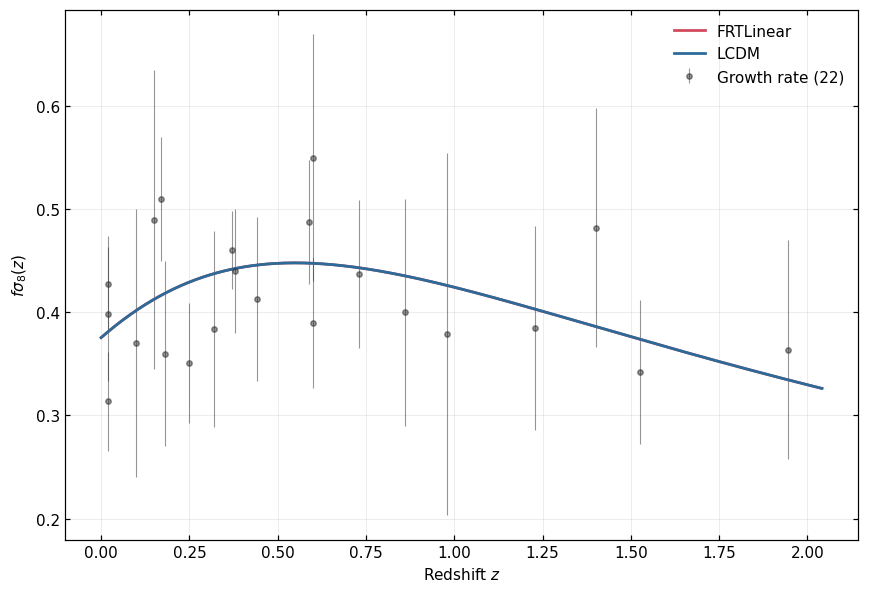

In [10]:
for name, model_cls, free_params in [
    ("FQExponential", FQExponential, ["Omega_m", "sigma8"]),
    ("FRTLinear", FRTLinear, ["Omega_m", "sigma8", "beta"]),
]:
    fit = Fitter(
        model=model_cls, datasets=["fsigma8"],
        free_params=free_params, initial=FIDUCIAL,
    )
    fit.best_fit()
    fig = fit.plots.compare_growth(labels=[name, "LCDM"])


## S8 weak-lensing prior: the "S8 tension" in one number

`"s8"` is a single Gaussian constraint on
S8 = sigma8*sqrt(Omega_m/0.3) from a weak-lensing survey. At a
Planck-like fiducial point (`sigma8=0.811`, `Omega_m=0.315`), the
model's S8 is already several sigma away from KiDS-1000's -- the
well-known "S8 tension", visible directly as a chi2.

In [11]:
from CosmoFit.likelihoods.s8 import S8Likelihood

lcdm_fid = LCDM(CosmologyParameters(H0=67.4, Omega_m=0.315, sigma8=0.811))
s8_kids = S8Likelihood(lcdm_fid, version="kids1000")
s8_des = S8Likelihood(lcdm_fid, version="des_y3")

print(f"model S8 = {s8_kids.model():.3f}")
print(f"KiDS-1000: S8_obs = {s8_kids.data.value:.3f} +/- {s8_kids.data.sigma:.3f}   "
      f"chi2 = {s8_kids.chi2():.2f}")
print(f"DES Y3:    S8_obs = {s8_des.data.value:.3f} +/- {s8_des.data.sigma:.3f}   "
      f"chi2 = {s8_des.chi2():.2f}")


model S8 = 0.831
KiDS-1000: S8_obs = 0.759 +/- 0.022   chi2 = 10.25
DES Y3:    S8_obs = 0.776 +/- 0.017   chi2 = 10.48


## Summary

- Background level: FQExponential and FRTLinear have their own
  E(z); FRHuSawicki's is exactly LCDM's.
- Growth level: every model's `mu(a,k)` (1 = GR by default) feeds a
  shared linear growth solver, giving fsigma8(z)/S8 for all of them
  -- not just the modified-gravity three.
- The concrete payoff: FRHuSawicki's `f_R0` is completely
  unconstrained by background-only data (flat chi2 across the whole
  prior) but genuinely constrained once `"fsigma8"`/`"s8"` are
  included.

## Next steps

- [`model_zoo_comparison.ipynb`](model_zoo_comparison.ipynb) -- the
  six background-expansion models (LCDM/wCDM/CPL/JBP/BA/GCG) compared
  with AIC/BIC.
- [`dataset_zoo.ipynb`](dataset_zoo.ipynb) -- a tour of every
  built-in dataset, including `"fsigma8"`/`"s8"`.
- Define your own modified-gravity model: `define_model()`/
  `model_from_expression()` now accept a `mu=` argument (effective
  gravitational coupling) alongside `E`, so a custom model can affect
  growth of structure too, not just the background -- see
  `cosmology/custom.py`.